In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('dane/fra_perfumes.csv')
print(f"Rozmiar początkowy bazy: {df.shape}")

Rozmiar początkowy bazy: (70103, 8)


In [5]:
df.head()

,Name,Gender,Rating Value,Rating Count,Main Accords,Perfumers,Description,url
0,9am Afnanfor women,for women,3.73,174,"['citrus', 'musky', 'woody', 'aromatic', 'warm...",[],9ambyAfnanis a fragrance for women. Top notes ...,https://www.fragrantica.com/perfume/Afnan/9am-...
1,9am Dive Afnanfor women and men,for women and men,4.29,842,"['fruity', 'woody', 'green', 'warm spicy', 'ar...",[],9am DivebyAfnanis a Aromatic Aquatic fragrance...,https://www.fragrantica.com/perfume/Afnan/9am-...
2,9am pour Femme Afnanfor women,for women,4.00,68,"['fruity', 'musky', 'amber', 'citrus', 'powder...",[],9am pour FemmebyAfnanis a Amber fragrance for ...,https://www.fragrantica.com/perfume/Afnan/9am-...
3,9pm Afnanfor men,for men,4.50,"6,865","['vanilla', 'amber', 'warm spicy', 'cinnamon',...",[],9pmbyAfnanis a Amber Vanilla fragrance for men...,https://www.fragrantica.com/perfume/Afnan/9pm-...
4,9pm pour Femme Afnanfor women,for women,3.49,63,"['woody', 'aromatic', 'rose', 'fruity', 'powde...",[],9pm pour FemmebyAfnanis a Amber Floral fragran...,https://www.fragrantica.com/perfume/Afnan/9pm-...


In [6]:
df = df.dropna(subset=['Name', 'Description'])

In [7]:
df['Rating Count'] = pd.to_numeric(df['Rating Count'], errors='coerce')
df['Rating Value'] = pd.to_numeric(df['Rating Value'], errors='coerce')
df = df.dropna(subset=['Rating Count', 'Rating Value'])

In [8]:
MIN_RATINGS = 50
df_cleaned = df[df['Rating Count'] >= MIN_RATINGS].copy()
df_cleaned = df_cleaned.reset_index(drop=True)

In [9]:
print(f"Rozmiar bazy po czyszczeniu (min. {MIN_RATINGS} ocen): {df_cleaned.shape}")

Rozmiar bazy po czyszczeniu (min. 50 ocen): (21704, 8)


In [10]:
import ast 

def clean_accords(accord_string):
    try:
        accords_list = ast.literal_eval(accord_string)
        return ", ".join(accords_list)
    except:
        return "" 

In [11]:
df_cleaned['Brand'] = df_cleaned['url'].str.extract(r'/perfume/([^/]+)/')
df_cleaned['Brand'] = df_cleaned['Brand'].str.replace('-', ' ')

df_cleaned['Perfume_ID'] = df_cleaned['url'].str.extract(r'-(\d+)\.html')

df_cleaned['Description'] = df_cleaned['Description'].str.replace(r'([a-zA-Z0-9])by([A-Z])', r'\1 by \2', regex=True)
df_cleaned['Description'] = df_cleaned['Description'].str.replace(r'([a-zA-Z])is a ', r'\1 is a ', regex=True)

df_cleaned['Clean_Accords'] = df_cleaned['Main Accords'].apply(clean_accords)

df_cleaned['Semantic_Text'] = df_cleaned['Description'] + " Main accords: " + df_cleaned['Clean_Accords'] + "."

print("Przykładowe wyciągnięte Marki i ID")
print(df_cleaned[['Brand', 'Perfume_ID', 'Clean_Accords']].head(3).to_string())

print("\nTekst Semantyczny (Semantic_Text)")
print(df_cleaned['Semantic_Text'].iloc[0])

Przykładowe wyciągnięte Marki i ID
   Brand Perfume_ID                                                                              Clean_Accords
0  Afnan      70706  citrus, musky, woody, aromatic, warm spicy, lavender, mossy, fruity, earthy, white floral
1  Afnan      78611  fruity, woody, green, warm spicy, aromatic, citrus, fresh, fresh spicy, soft spicy, amber
2  Afnan      78541                         fruity, musky, amber, citrus, powdery, sweet, animalic, soft spicy

Tekst Semantyczny (Semantic_Text)
9am by Afnan is a fragrance for women. Top notes are Lemon, Mandarin Orange, Cardamom and Pink Pepper; middle notes are Lavender, Green Apple, Orange Blossom and Rose; base notes are Musk, Moss, Cedar and Patchouli. Main accords: citrus, musky, woody, aromatic, warm spicy, lavender, mossy, fruity, earthy, white floral.


In [12]:
df_cleaned.head()

,Name,Gender,Rating Value,Rating Count,Main Accords,Perfumers,Description,url,Brand,Perfume_ID,Clean_Accords,Semantic_Text
0,9am Afnanfor women,for women,3.73,174.0,"['citrus', 'musky', 'woody', 'aromatic', 'warm...",[],9am by Afnan is a fragrance for women. Top not...,https://www.fragrantica.com/perfume/Afnan/9am-...,Afnan,70706,"citrus, musky, woody, aromatic, warm spicy, la...",9am by Afnan is a fragrance for women. Top not...
1,9am Dive Afnanfor women and men,for women and men,4.29,842.0,"['fruity', 'woody', 'green', 'warm spicy', 'ar...",[],9am Dive by Afnan is a Aromatic Aquatic fragra...,https://www.fragrantica.com/perfume/Afnan/9am-...,Afnan,78611,"fruity, woody, green, warm spicy, aromatic, ci...",9am Dive by Afnan is a Aromatic Aquatic fragra...
2,9am pour Femme Afnanfor women,for women,4.00,68.0,"['fruity', 'musky', 'amber', 'citrus', 'powder...",[],9am pour Femme by Afnan is a Amber fragrance f...,https://www.fragrantica.com/perfume/Afnan/9am-...,Afnan,78541,"fruity, musky, amber, citrus, powdery, sweet, ...",9am pour Femme by Afnan is a Amber fragrance f...
3,9pm pour Femme Afnanfor women,for women,3.49,63.0,"['woody', 'aromatic', 'rose', 'fruity', 'powde...",[],9pm pour Femme by Afnan is a Amber Floral frag...,https://www.fragrantica.com/perfume/Afnan/9pm-...,Afnan,78544,"woody, aromatic, rose, fruity, powdery, violet...",9pm pour Femme by Afnan is a Amber Floral frag...
4,Black Oudh Al Haramain Perfumesfor women and men,for women and men,4.12,113.0,"['woody', 'powdery', 'musky', 'amber', 'patcho...",[],Black Oudh by Al Haramain Perfumes is a Amber ...,https://www.fragrantica.com/perfume/Al-Haramai...,Al Haramain Perfumes,36596,"woody, powdery, musky, amber, patchouli, vanil...",Black Oudh by Al Haramain Perfumes is a Amber ...


In [13]:
def extract_clean_name(row):
    full_name = str(row['Name']).strip()
    gender_val = str(row['Gender']).strip()
    brand_val = str(row['Brand']).strip()
    
    if full_name.endswith(gender_val):
        full_name = full_name[:-len(gender_val)].strip()
        
    if full_name.lower().endswith(brand_val.lower()):
        full_name = full_name[:-len(brand_val)].strip()
        
    return full_name

In [14]:
df_cleaned['Clean_Name'] = df_cleaned.apply(extract_clean_name, axis=1)

df_cleaned['Semantic_Text'] = "Perfume: " + df_cleaned['Clean_Name'] + " by " + df_cleaned['Brand'] + ". " + df_cleaned['Description'] + " Main accords: " + df_cleaned['Clean_Accords'] + "."

print("Porównanie starej nazwy i nowej, czystej nazwy")
print(df_cleaned[['Name', 'Brand', 'Gender', 'Clean_Name']].head(5).to_string())

Porównanie starej nazwy i nowej, czystej nazwy
                                               Name                 Brand             Gender      Clean_Name
0                                9am Afnanfor women                 Afnan          for women             9am
1                   9am Dive Afnanfor women and men                 Afnan  for women and men        9am Dive
2                     9am pour Femme Afnanfor women                 Afnan          for women  9am pour Femme
3                     9pm pour Femme Afnanfor women                 Afnan          for women  9pm pour Femme
4  Black Oudh Al Haramain Perfumesfor women and men  Al Haramain Perfumes  for women and men      Black Oudh


In [15]:
df_cleaned = df_cleaned.drop(columns=['Name'])
df_cleaned = df_cleaned.rename(columns={'Clean_Name': 'Name'})
new_order = [
    'Perfume_ID', 'Name', 'Brand', 'Gender', 'Rating Value', 'Rating Count', 
    'Clean_Accords', 'Description', 'Semantic_Text', 'url', 'Main Accords'
]

df_cleaned = df_cleaned[new_order]

df_cleaned.head()

,Perfume_ID,Name,Brand,Gender,Rating Value,Rating Count,Clean_Accords,Description,Semantic_Text,url,Main Accords
0,70706,9am,Afnan,for women,3.73,174.0,"citrus, musky, woody, aromatic, warm spicy, la...",9am by Afnan is a fragrance for women. Top not...,Perfume: 9am by Afnan. 9am by Afnan is a fragr...,https://www.fragrantica.com/perfume/Afnan/9am-...,"['citrus', 'musky', 'woody', 'aromatic', 'warm..."
1,78611,9am Dive,Afnan,for women and men,4.29,842.0,"fruity, woody, green, warm spicy, aromatic, ci...",9am Dive by Afnan is a Aromatic Aquatic fragra...,Perfume: 9am Dive by Afnan. 9am Dive by Afnan ...,https://www.fragrantica.com/perfume/Afnan/9am-...,"['fruity', 'woody', 'green', 'warm spicy', 'ar..."
2,78541,9am pour Femme,Afnan,for women,4.00,68.0,"fruity, musky, amber, citrus, powdery, sweet, ...",9am pour Femme by Afnan is a Amber fragrance f...,Perfume: 9am pour Femme by Afnan. 9am pour Fem...,https://www.fragrantica.com/perfume/Afnan/9am-...,"['fruity', 'musky', 'amber', 'citrus', 'powder..."
3,78544,9pm pour Femme,Afnan,for women,3.49,63.0,"woody, aromatic, rose, fruity, powdery, violet...",9pm pour Femme by Afnan is a Amber Floral frag...,Perfume: 9pm pour Femme by Afnan. 9pm pour Fem...,https://www.fragrantica.com/perfume/Afnan/9pm-...,"['woody', 'aromatic', 'rose', 'fruity', 'powde..."
4,36596,Black Oudh,Al Haramain Perfumes,for women and men,4.12,113.0,"woody, powdery, musky, amber, patchouli, vanil...",Black Oudh by Al Haramain Perfumes is a Amber ...,Perfume: Black Oudh by Al Haramain Perfumes. B...,https://www.fragrantica.com/perfume/Al-Haramai...,"['woody', 'powdery', 'musky', 'amber', 'patcho..."


In [ ]:
# === TASK 1.5: Generowanie Embeddingów (SBERT) ===
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print("Generowanie wektorów.")

embeddings = model.encode(df_cleaned['Semantic_Text'].tolist(), show_progress_bar=True)

print("Generowanie wektorów zakończone.")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

c:\Users\tomas\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\tomas\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Rozpoczynam generowanie wektorów...


Batches:   0%|          | 0/679 [00:00<?, ?it/s]

Generowanie wektorów zakończone.


In [ ]:
# === TASK 1.4: Usuwanie anomalii (Isolation Forest) ===
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(n_estimators=100, contamination=0.02, random_state=42)

predictions = iso_forest.fit_predict(embeddings)

df_cleaned['Embedding'] = list(embeddings)
df_cleaned['Anomaly'] = predictions

df_final = df_cleaned[df_cleaned['Anomaly'] == 1].copy()

df_final = df_final.drop(columns=['Anomaly'])

print(f"Rozmiar bazy przed usunięciem anomalii: {df_cleaned.shape[0]}")
print(f"Rozmiar bazy po czyszczeniu (gotowej do klastrowania): {df_final.shape[0]}")

Rozmiar bazy przed usunięciem anomalii: 21704
Rozmiar bazy po czyszczeniu (gotowej do klastrowania): 21269


In [25]:
# === TASK 1.6: Grupowanie zapachów (PCA + K-Means) ===
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

X_embeddings = np.array(df_final['Embedding'].tolist())

print("Redukcja PCA do 111 wymiarów")
pca = PCA(n_components=111, random_state=42)
X_reduced = pca.fit_transform(X_embeddings)
explained_var = pca.explained_variance_ratio_.sum()
print(f"Wyjaśniona wariancja przez 50 składowych: {explained_var * 100:.2f}%")

print("Grupowanie K-Means")
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_reduced)

sil_score = silhouette_score(X_reduced, cluster_labels)
print(f"Silhouette Score dla 5 klastrów: {sil_score:.4f}")

df_final['Cluster_ID'] = cluster_labels

df_final['PCA_X'] = X_reduced[:, 0] 
df_final['PCA_Y'] = X_reduced[:, 1]

cluster_names = {
    0: "Ciężkie-Wieczorowe",
    1: "Świeże-Cytrusowe",
    2: "Kwiatowo-Owocowe",
    3: "Mroczne-Drzewne",
    4: "Orientalno-Przyprawowe"
}
df_final['Cluster_Name'] = df_final['Cluster_ID'].map(cluster_names)

Redukcja PCA do 111 wymiarów
Wyjaśniona wariancja przez 50 składowych: 90.02%
Grupowanie K-Means
Silhouette Score dla 5 klastrów: 0.0151


==============TESTY==============

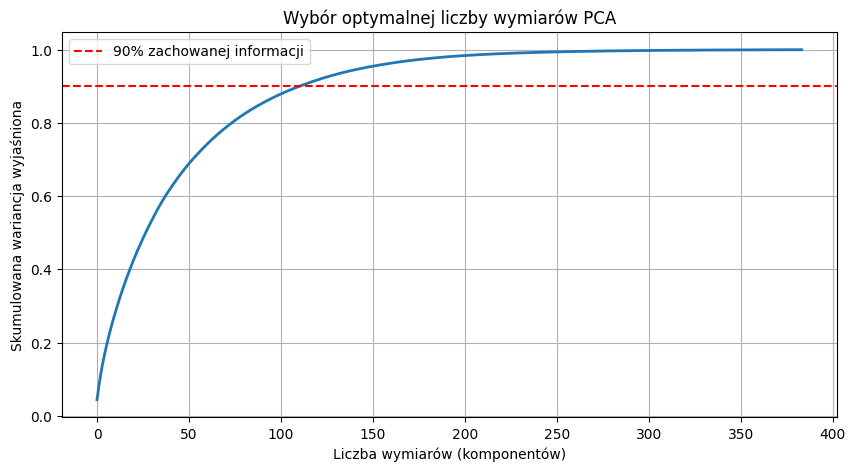

Aby zachować 90% informacji, potrzebujesz 111 wymiarów.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

pca_test = PCA(random_state=42)
pca_test.fit(X_embeddings)

cumsum = np.cumsum(pca_test.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(cumsum, linewidth=2)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% zachowanej informacji')
plt.xlabel('Liczba wymiarów (komponentów)')
plt.ylabel('Skumulowana wariancja wyjaśniona')
plt.title('Wybór optymalnej liczby wymiarów PCA')
plt.legend()
plt.grid(True)
plt.show()

optimal_dimensions = np.argmax(cumsum >= 0.90) + 1
print(f"Aby zachować 90% informacji, potrzebujesz {optimal_dimensions} wymiarów.")

Trenowanie modeli dla różnej liczby klastrów.


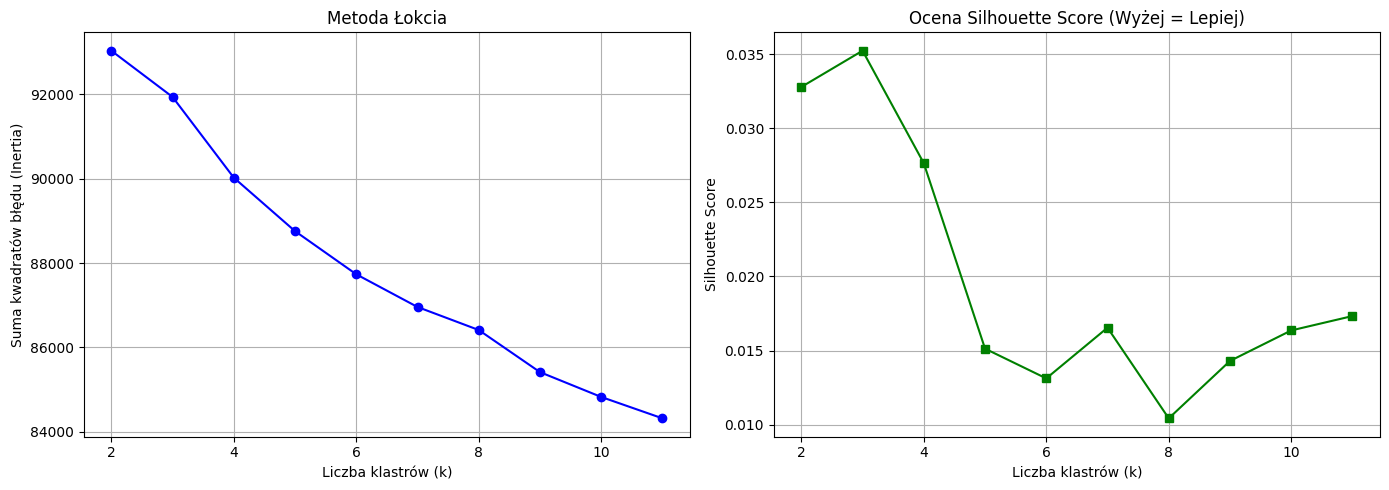

Najwyższy Silhouette Score uzyskano dla k = 3


In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sse = []
silhouette_scores = []
k_range = range(2, 12) 

print("Trenowanie modeli dla różnej liczby klastrów.")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_reduced)
    
    sse.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_reduced, labels))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, sse, marker='o', color='b')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Suma kwadratów błędu (Inertia)')
plt.title('Metoda Łokcia')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='s', color='g')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Silhouette Score')
plt.title('Ocena Silhouette Score (Wyżej = Lepiej)')
plt.grid(True)

plt.tight_layout()
plt.show()

best_k = k_range[np.argmax(silhouette_scores)]
print(f"Najwyższy Silhouette Score uzyskano dla k = {best_k}")